In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from functions import F_P, GradientKernel,KernelGradientDiscrepancy
import jax_kernels as ker
from variational_inference import VariationalInference
import functions as f

import jax
from jax import random

In [2]:
device_name = "cpu"

In [3]:
c = 1
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    return jnp.exp(-jnp.linalg.norm(x)**2/2) #/ jnp.sqrt((2 *jnp.pi)**d)

def v(X):
    return -1/4 * jnp.linalg.norm(X, axis=1)**2 

def L(X):
    return jnp.mean(v(X))

k = jit(k)
q_0 = jit(q_0)
v = jit(v)
L = jit(L)


In [19]:
eta = 0.1
T = 1000
d = 2

VI = VariationalInference(q_0,L,k,d)

# theta0 = flat_params
W0 = random.normal(random.PRNGKey(2), (1000, d))
#X0 = VI.model(Theta[0], W0)

key = random.PRNGKey(1)
Theta = VI.run(key,eta,T)
theta_fin = Theta[-1]

W_fin = random.normal(random.PRNGKey(2), (100, d))
X_fin = VI.model(theta_fin, W_fin)
X = [VI.model(theta, W0) for theta in Theta]

In [25]:
# F_P = f.F_P(q_0, L)
# k_pq = f.GradientKernel(VI.S_PQ,k)
# KGD = f.KernelGradientDiscrepancy(k_pq)

# KGD_fin = jnp.zeros(T)
# # # KDE_KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
# # # F_P_fin = jax.device_put(jnp.zeros(len(Eta)), device)
# # # L_fin = jax.device_put(jnp.zeros(len(Eta)), device)

# for it in range(T):
#     KGD_fin = KGD_fin.at[it].set(KGD.evaluate(X[it]))
# #     # KDE_KGD_fin = KDE_KGD_fin.at[e].set(KGD.kde_KGD(X,num_samples = 300))
# #     # F_P_fin = F_P_fin.at[e].set(F_P.evaluate(X,num_samples = 300))
# #     # L_fin = L_fin.at[e].set(L(X))
    

In [26]:
# plt.plot(KGD_fin)

/var/folders/zl/0c18q_l567xgnm85cwp5t7xm0000gp/T/ipykernel_89133/1282930690.py:37: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X, Y, Z, levels=10, cmap='viridis', alpha=0.7, label='Gaussian contours')


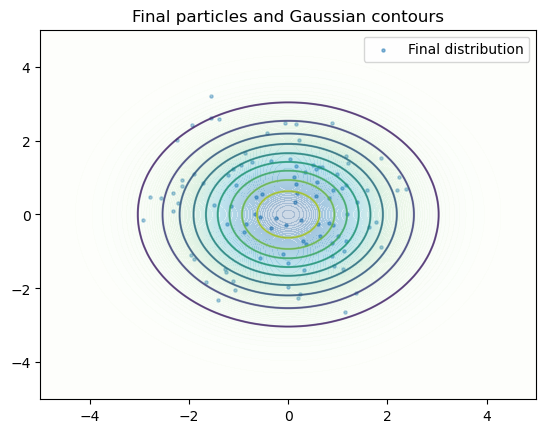

In [22]:
plt.scatter(X_fin[:, 0], X_fin[:, 1], s=5, alpha=0.5,label='Final distribution')
#plt.scatter(X0[:, 0], X0[:, 1], s=1, alpha=0.5,label = 'Initial distribution')
plt.legend()

import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax.scipy.stats import multivariate_normal

# Paramètres de la distribution
mean = jnp.zeros(2)  # Moyenne (0, 0)
cov = jnp.eye(2) * 2.0  # Matrice de covariance (2 * identité)

# Grille pour les lignes de niveau
x = jnp.linspace(-5, 5, 100)
y = jnp.linspace(-5, 5, 100)
X, Y = jnp.meshgrid(x, y)
pos = jnp.dstack((X, Y))

cf = plt.contourf(
        X, Y, Z, 
        levels=100,          # plus de niveaux pour un dégradé lisse
        cmap='GnBu', 
        alpha=0.2     # transparence du fond
    )

  # Lignes de contour par-dessus
plt.contour(
    X, Y, Z, 
    levels=10, 
    colors='black', 
    linewidths=0.8,
    alpha=0.5)
# Calcul de la densité de probabilité
Z = multivariate_normal.pdf(pos, mean, cov)

# 
plt.contour(X, Y, Z, levels=10, cmap='viridis', alpha=0.7, label='Gaussian contours')
plt.title("Final particles and Gaussian contours")
plt.legend()
plt.show()